# JobKB — Base de connaissances Occupations ↔ Compétences (IT)

In [1]:
import sys, os, re, math
sys.path.insert(0, os.path.abspath('..'))          # make `src` importable from notebooks/
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Markdown, display

from src import config as C, common as K, hierarchy as H
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 170)

def load(p):
    return pd.DataFrame(K.read_all(p)) if os.path.isfile(p) else pd.DataFrame()
def nonempty(df, col):
    return 0 if (df.empty or col not in df) else int((df[col].fillna('').astype(str).str.strip() != '').sum())

occ  = load(C.OCCUPATIONS_CSV);          skl  = load(C.SKILLS_CSV)
uocc = load(C.UNIFIED_OCCUPATIONS_CSV);   uskl = load(C.UNIFIED_SKILLS_CSV)
hier = load(C.HIERARCHY_CSV);             rel  = load(C.OCC_SKILL_REL_CSV)
TAXO = list(C.TAXONOMY_SKILL_MARKERS)
real_occ = occ[occ.occupation_type != 'isco_group']
real_skl = skl[~skl.esco_skill_type.isin(TAXO)]
allc = pd.concat([uocc, uskl], ignore_index=True)
print(f"loaded  ·  {len(uocc)} unified occupations  ·  {len(uskl)} unified skills  ·  "
      f"{len(rel)} relations  ·  {len(hier)} hierarchy edges")

loaded  ·  292 unified occupations  ·  11136 unified skills  ·  34697 relations  ·  12769 hierarchy edges


## Partie 0 · Contexte & objectifs

**Le problème.** Le marché de l'emploi IT est décrit par de multiples **référentiels publics hétérogènes** — ISCO (international), ESCO (UE), O\*NET (US), NOC (Canada), ROME (France) — qui ne partagent **aucune table de correspondance** (pas de crosswalk ISCO↔SOC↔NOC↔ROME dans ces données), emploient des **langues** et des **granularités** différentes, et se recouvrent partiellement. Il manque une base **unifiée** reliant *occupations* et *compétences* (hard/soft), **dédoublonnée**, exploitable pour des systèmes de **recommandation**.

**L'objectif.** Construire cette base : périmètre strictement **IT** (+ managers & data), **anglais-primaire** (français secondaire), doublons **fusionnés** en concepts uniques, processus **entièrement automatique et agentique**, **passant à l'échelle**.

In [2]:
# Carte d'identité du KB — chiffres calculés en direct sur kb/ (lecture seule)
kpi = {
    'Occupations réelles': len(real_occ),
    'Groupes ISCO (squelette)': len(occ) - len(real_occ),
    'Compétences (hors nœuds de taxonomie)': len(real_skl),
    'Concepts unifiés — occupations': len(uocc),
    'Concepts unifiés — compétences': len(uskl),
    'Relations occupation→compétence': len(rel),
    'Arêtes de hiérarchie': len(hier),
    'Concepts ancrés à Wikidata (QID)': nonempty(allc, 'wikidata_qid'),
    'Labels EN / FR (concepts unifiés)': f"{nonempty(allc, 'primary_label_en')} / {nonempty(allc, 'primary_label_fr')}",
}
display(pd.Series(kpi, name='valeur').to_frame())
print('cohérence logique auto-certifiée à chaque build — détail en Partie 2 (consistency 13/13).')

,valeur
Occupations réelles,308
Groupes ISCO (squelette),24
Compétences (hors nœuds de taxonomie),12098
Concepts unifiés — occupations,292
Concepts unifiés — compétences,11136
Relations occupation→compétence,34697
Arêtes de hiérarchie,12769
Concepts ancrés à Wikidata (QID),1201
Labels EN / FR (concepts unifiés),11408 / 11041


cohérence logique auto-certifiée à chaque build — détail en Partie 2 (consistency 13/13).


## Partie 1 · Architecture & pipeline

`ingest → hierarchy → align → attach → merge → qa (quality assurance)`

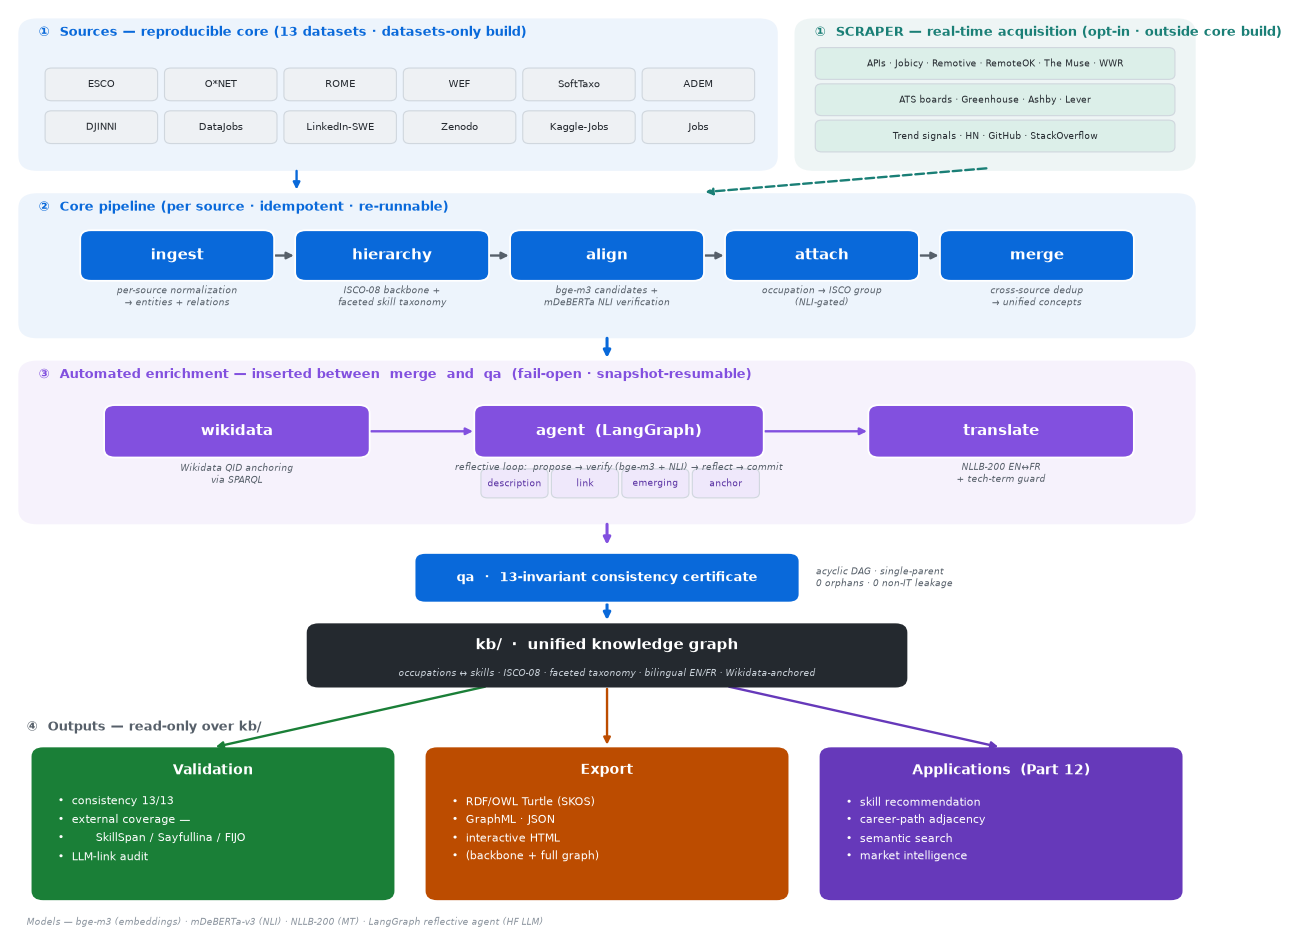

In [5]:
# Detailed system architecture of JobKB (standalone matplotlib · read-only)
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(13.5, 9.6)); ax.axis('off')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
BLUE, PURPLE, TEAL = '#0969da', '#8250df', '#1a7f76'
GREEN, ORANGE, INDIGO = '#1a7f37', '#bc4c00', '#6639ba'

def band(x, y, w, h, fc, title=None, alpha=0.07):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.3,rounding_size=1.6',
                 fc=fc, ec=fc, alpha=alpha, lw=0, zorder=0))
    if title:
        ax.text(x + 1.4, y + h - 0.5, title, ha='left', va='top', fontsize=9, weight='bold', color=fc, zorder=4)

def box(x, y, w, h, text, fc, fs=9.5, tc='white', weight='bold', ec='white'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12,rounding_size=0.9',
                 fc=fc, ec=ec, lw=1.3, zorder=3))
    if text:
        ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', color=tc, fontsize=fs, weight=weight, zorder=4)

def chip(x, y, w, h, text, fs=7.2, fc='#eef1f4', tc='#24292f'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.06,rounding_size=0.55',
                 fc=fc, ec='#d0d7de', lw=0.8, zorder=3))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', color=tc, fontsize=fs, zorder=4)

def cap(x, y, text, color='#57606a', fs=6.5):
    ax.text(x, y, text, ha='center', va='top', fontsize=fs, color=color, style='italic', zorder=4)

def arr(x1, y1, x2, y2, color='#57606a', lw=1.7, ls='-'):
    ax.annotate('', (x2, y2), (x1, y1),
                arrowprops=dict(arrowstyle='-|>', lw=lw, color=color, linestyle=ls), zorder=1)

# ── (1) SOURCES ──────────────────────────────────────────────────────────────────
band(1, 83, 63, 15.8, BLUE, title='①  Sources — reproducible core (13 datasets · datasets-only build)')
for i, name in enumerate(['ESCO', 'O*NET', 'ROME', 'WEF', 'SoftTaxo', 'ADEM',
                          'DJINNI', 'DataJobs', 'LinkedIn-SWE', 'Zenodo', 'Kaggle-Jobs', 'Jobs']):
    r, c = divmod(i, 6)
    chip(3 + c * 10.0, 90.3 - r * 4.6, 9.3, 3.4, name)
band(66, 83, 33, 15.8, TEAL, title='①  SCRAPER — real-time acquisition (opt-in · outside core build)')
chip(67.5, 92.6, 30, 3.3, 'APIs · Jobicy · Remotive · RemoteOK · The Muse · WWR', fs=6.4, fc='#dcefe9')
chip(67.5, 88.7, 30, 3.3, 'ATS boards · Greenhouse · Ashby · Lever', fs=6.4, fc='#dcefe9')
chip(67.5, 84.8, 30, 3.3, 'Trend signals · HN · GitHub · StackOverflow', fs=6.4, fc='#dcefe9')
arr(24, 83, 24, 80.4, BLUE); arr(82, 83, 58, 80.4, TEAL, ls='--')

# ── (2) CORE PIPELINE ────────────────────────────────────────────────────────────
band(1, 65, 98, 15, BLUE, title='②  Core pipeline (per source · idempotent · re-runnable)')
core = [('ingest', 'per-source normalization\n→ entities + relations'),
        ('hierarchy', 'ISCO-08 backbone +\nfaceted skill taxonomy'),
        ('align', 'bge-m3 candidates +\nmDeBERTa NLI verification'),
        ('attach', 'occupation → ISCO group\n(NLI-gated)'),
        ('merge', 'cross-source dedup\n→ unified concepts')]
xs, X, W, G, YS = [], 6.0, 16.0, 2.0, 71.0
for name, capt in core:
    box(X, YS, W, 5.2, name, BLUE, fs=10.5)
    cap(X + W / 2, YS - 0.5, capt)
    xs.append((X, X + W)); X += W + G
for i in range(len(xs) - 1):
    arr(xs[i][1], YS + 2.6, xs[i + 1][0], YS + 2.6)
arr(50, 65, 50, 62.3, BLUE, lw=2.2)

# ── (3) AUTOMATED ENRICHMENT ─────────────────────────────────────────────────────
band(1, 45, 98, 17, PURPLE,
     title='③  Automated enrichment — inserted between  merge  and  qa  (fail-open · snapshot-resumable)')
box(8, 52, 22, 5.4, 'wikidata', PURPLE, fs=10.5)
box(39, 52, 24, 5.4, 'agent  (LangGraph)', PURPLE, fs=10.5)
box(72, 52, 22, 5.4, 'translate', PURPLE, fs=10.5)
arr(30, 54.7, 39, 54.7, PURPLE); arr(63, 54.7, 72, 54.7, PURPLE)
cap(19, 51.4, 'Wikidata QID anchoring\nvia SPARQL')
cap(51, 51.4, 'reflective loop:  propose → verify (bge-m3 + NLI) → reflect → commit')
cap(83, 51.4, 'NLLB-200 EN↔FR\n+ tech-term guard')
for i, wname in enumerate(['description', 'link', 'emerging', 'anchor']):
    chip(39.5 + i * 5.9, 47.6, 5.5, 3.0, wname, fs=6.5, fc='#efe8fb', tc='#5a32a3')
arr(50, 45, 50, 42.2, PURPLE, lw=2.2)

# ── qa gate + kb/ ────────────────────────────────────────────────────────────────
box(34, 36.4, 32, 5.1, 'qa  ·  13-invariant consistency certificate', BLUE, fs=9.5)
ax.text(67.5, 39.0, 'acyclic DAG · single-parent\n0 orphans · 0 non-IT leakage',
        ha='left', va='center', fontsize=6.3, color='#57606a', style='italic', zorder=4)
arr(50, 36.4, 50, 34.1, BLUE, lw=2.2)
ax.add_patch(FancyBboxPatch((25, 27.3), 50, 6.6, boxstyle='round,pad=0.15,rounding_size=1.0',
             fc='#24292f', ec='#24292f', lw=0, zorder=3))
ax.text(50, 31.7, 'kb/  ·  unified knowledge graph',
        ha='center', va='center', color='white', fontsize=11, weight='bold', zorder=4)
ax.text(50, 28.7, 'occupations ↔ skills · ISCO-08 · faceted taxonomy · bilingual EN/FR · Wikidata-anchored',
        ha='center', va='center', color='#c9d1d9', fontsize=6.7, style='italic', zorder=4)

# ── (4) OUTPUTS ──────────────────────────────────────────────────────────────────
def outbox(x, color, title, lines):
    box(x, 4.5, 30, 16, '', color, ec=color)
    ax.text(x + 15, 19.0, title, ha='center', va='top', color='white', fontsize=10, weight='bold', zorder=5)
    ax.text(x + 2.0, 15.9, '\n'.join('•  ' + l for l in lines), ha='left', va='top',
            color='white', fontsize=7.7, zorder=5, linespacing=1.7)
ax.text(1.4, 23.6, '④  Outputs — read-only over kb/', ha='left', va='top', fontsize=9, weight='bold', color='#57606a')
outbox(2, GREEN, 'Validation',
       ['consistency 13/13', 'external coverage —', '      SkillSpan / Sayfullina / FIJO', 'LLM-link audit'])
outbox(35, ORANGE, 'Export',
       ['RDF/OWL Turtle (SKOS)', 'GraphML · JSON', 'interactive HTML', '(backbone + full graph)'])
outbox(68, INDIGO, 'Applications  (Part 12)',
       ['skill recommendation', 'career-path adjacency', 'semantic search', 'market intelligence'])
arr(40, 27.3, 17, 20.7, GREEN); arr(50, 27.3, 50, 20.7, ORANGE); arr(60, 27.3, 83, 20.7, INDIGO)

ax.text(1.4, 1.4, 'Models — bge-m3 (embeddings) · mDeBERTa-v3 (NLI) · NLLB-200 (MT) · LangGraph reflective agent (HF LLM)',
        ha='left', va='bottom', fontsize=6.4, color='#8b949e', style='italic', zorder=4)

plt.tight_layout(); plt.show()


In [4]:
# Sources récapitulées (rôle + apport chiffré), lues depuis kb/
occ_by = occ[occ.occupation_type != 'isco_group'].source.value_counts()
skl_by = real_skl.source.value_counts()
rel_by = rel.source.value_counts()
srcs = sorted(set(occ_by.index) | set(skl_by.index) | set(rel_by.index))
sdf = pd.DataFrame([{'source': s, 'occupations': int(occ_by.get(s, 0)),
                     'skills': int(skl_by.get(s, 0)), 'relations': int(rel_by.get(s, 0))}
                    for s in srcs]).sort_values(['occupations', 'skills', 'relations'], ascending=False)
print(f'{len(srcs)} sources contribuent au KB  (occupations / compétences / relations) :')
display(sdf.reset_index(drop=True))

22 sources contribuent au KB  (occupations / compétences / relations) :


,source,occupations,skills,relations
0,ESCO,110,1894,6613
1,ROME,93,2052,5146
2,SCRAPER,52,11,1577
3,ONET,32,1493,6589
4,NOC,15,0,0
5,EMERGING,6,0,0
6,LIGHTCAST,0,5243,0
7,KAGGLE,0,528,0
8,CSO,0,527,0
9,SFIA,0,95,0


## Partie 2 · Intégrité & cohérence logique

In [5]:
from src import pipeline
qa = pipeline.qa()          # prints the full integrity + coverage report


=== QA ===
occupations: 280 (256 real, 24 ISCO groups)
skills: 12087 (+34 taxonomy nodes)  |  hierarchy edges: 12654  |  dangling: 0
skill taxonomy: 2 types / 10 domains / 22 categories  |  occupations linked to a functional domain: 256/256
EN label coverage (real occ): 163/256
occupation orphans (no hierarchy parent): 0
low-confidence ISCO attachments (review): 7
skills not placed in ontology: 0
non-IT ISCO group leakage: 0
relevance gate — blocked: 5 (non-IT 5, malformed 0); borderline-kept: 3
occupation-skill relations: 33120 (demand: 8234 — ADEM 1528, DATAJOBS 1275, DJINNI 2281, JOBS 1545, KAGGLE_JOBS 166, LINKEDIN_SWE 898, ZENODO 541)  |  dangling refs: 0
wikidata anchors: 1202 (1163 skills, 31 occupations, 8 domains; 1038 high-confidence)


wikidata in-graph: 1163 skills + 31 occupations carry a QID; 1134 carry a Wikidata description  |  dangling anchors: 0
descriptions: 3322/11366 concepts (by source: {'source': 2305, 'llm': 27, 'wikidata': 990})  |  hard_soft: 11126/11126 skills
llm enrichment: 27 descriptions, 38 inferred links, 0 new Wikidata-confirmed skills; 3 outputs rejected by validation
label coverage: primary EN 11346/11366, FR 10980/11366  |  alt EN 3061/11366, FR 893/11366
translation: validated MT by direction {'en_fr': 6167, 'fr_en': 2084}; 408 rejected by validation


consistency: 13/13 invariants PASS


In [6]:
# nos indicateurs de consistence
from src.validation import consistency
res = consistency.check()
cdf = pd.DataFrame(res, columns=['invariant', 'pass', 'detail'])
display(cdf)
assert bool(cdf['pass'].all()), "LOGICAL CONSISTENCY FAILED"
print(f"consistency: {int(cdf['pass'].sum())}/{len(cdf)} invariants PASS")

,invariant,pass,detail
0,hierarchy: no dangling edges,True,0 dangling
1,hierarchy: no self-loops,True,0 self-loops
2,hierarchy: acyclic (DAG),True,
3,skills: exactly one category parent,True,"0 multi-parent, 0 unplaced"
4,occupations: one backbone + one domain parent,True,"0 bad backbone, 0 bad facet"
5,"ISCO backbone: single root, all reach it",True,"1 roots, 0 unreachable"
6,ISCO: no non-IT group leakage,True,0 leaked groups
7,no skill->skill hierarchy edges,True,0 skill->skill edges
8,skills: hard_soft matches taxonomy,True,"0 mismatched, 0 empty"
9,relations: endpoints correctly typed,True,"0 bad occ, 0 bad skill endpoints"


consistency: 13/13 invariants PASS


## Partie 3 · Le KB en chiffres

In [7]:
dash = {
    'unified occupations': len(uocc),
    'unified skills': len(uskl),
    'occupation–skill relations': len(rel),
    'hierarchy edges': len(hier),
    'concepts with a description': nonempty(allc, 'description'),
    'primary label EN': nonempty(allc, 'primary_label_en'),
    'primary label FR': nonempty(allc, 'primary_label_fr'),
    'Wikidata-anchored concepts': nonempty(allc, 'wikidata_qid'),
    'skills with hard/soft set': f"{nonempty(uskl, 'hard_soft')}/{len(uskl)}",
}
display(pd.Series(dash, name='count').to_frame())
by_src = Counter(r for r in allc[allc.description.fillna('') != ''].get('description_source', []))
print('descriptions by source:', dict(by_src))

,count
unified occupations,240
unified skills,11126
occupation–skill relations,33120
hierarchy edges,12654
concepts with a description,3322
primary label EN,11346
primary label FR,10980
Wikidata-anchored concepts,1194
skills with hard/soft set,11126/11126


descriptions by source: {'source': 2305, 'llm': 27, 'wikidata': 990}


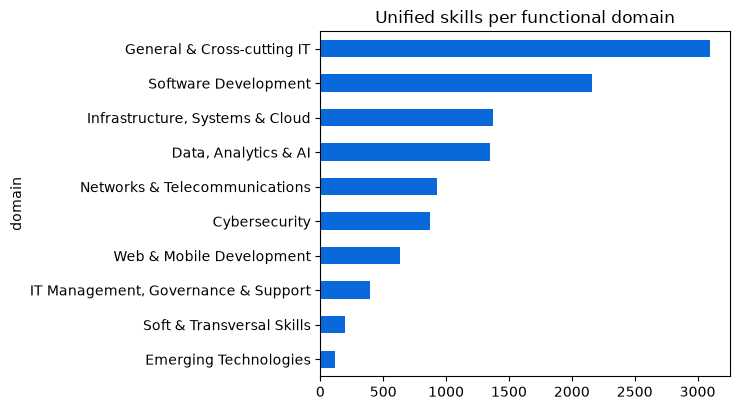

In [8]:
def skill_domain(sub):
    cat = H.CATEGORIES.get(sub)
    dom = H.DOMAINS.get(cat[0]) if cat else None
    return dom[1] if dom else 'other'
uskl = uskl.copy(); uskl['domain'] = uskl.it_subtype.map(skill_domain)
counts = uskl['domain'].value_counts()
ax = counts.plot.barh(figsize=(7.5, 4.2), color='#0969da')
ax.set_title('Unified skills per functional domain'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Partie 4 · Taxonomie facettée (4 niveaux)

L'ontologie est **facettée** autour d'une couche de **domaines fonctionnels partagée**. Les compétences suivent `compétence → catégorie (22) → domaine (10) → type (hard/soft)`

In [9]:
tx = skl[skl.esco_skill_type.isin(TAXO)]
print('taxonomy tiers:', dict(tx.esco_skill_type.value_counts()))
facet = hier[(hier.entity_kind == 'occupation') & (hier.relation_type == 'in_domain')]
print(f'occupation→domain facet coverage: {facet.child_entity_id.nunique()}/{len(real_occ)}')
print('hierarchy relation types:', dict(hier.relation_type.value_counts()))

taxonomy tiers: {'skill_category': np.int64(22), 'skill_domain': np.int64(10), 'skill_type': np.int64(2)}
occupation→domain facet coverage: 256/256
hierarchy relation types: {'broader_than': np.int64(12398), 'in_domain': np.int64(256)}


## Partie 5 · Intégration : alignement inter-sources & dédoublonnage

In [10]:
def n_members(s):
    return s.fillna('').apply(lambda v: len([x for x in v.split(' | ') if x]))
uskl['n_members'] = n_members(uskl.member_entity_ids)
uocc2 = uocc.copy(); uocc2['n_members'] = n_members(uocc2.member_entity_ids)
print(f"multi-source unified skills: {(uskl.n_members > 1).sum()}  ·  "
      f"multi-source unified occupations: {(uocc2.n_members > 1).sum()}")
display(uskl[uskl.n_members > 1].nlargest(8, 'n_members')[['primary_label_en', 'sources', 'n_members']])

multi-source unified skills: 709  ·  multi-source unified occupations: 13


,primary_label_en,sources,n_members
893,Machine Learning,CSO | ESCO | KAGGLE | LIGHTCAST | ROME | SFIA,6
2189,Microsoft Windows,CSO | DATAJOBS | KAGGLE | LIGHTCAST | ONET | Z...,6
4513,Virtualization,KAGGLE | LIGHTCAST | ROME,6
547,Database Management Systems,ESCO | LIGHTCAST | ONET | ROME,5
996,Ruby,ESCO | KAGGLE | LIGHTCAST | ONET | ROME,5
1179,Blockchain,ESCO | KAGGLE | LIGHTCAST | ROME,5
1457,Jenkins,DATAJOBS | ESCO | KAGGLE | LIGHTCAST | ZENODO,5
1749,MySQL,ESCO | KAGGLE | LIGHTCAST | ONET | ROME,5


## Partie 6 · Relations occupation ↔ compétence

In [11]:
print('relation types:', dict(rel.relation_type.value_counts()))
dem = rel[rel.relation_type == 'demand'].copy()
print('demand by source:', dict(dem.source.value_counts()))
lbl = dict(zip(skl.entity_id, skl.pref_label_en)); olbl = dict(zip(occ.entity_id, occ.pref_label_en))
top = dem.occupation_entity_id.value_counts().index[0]
print('\nsample — most-demanded skills for:', olbl.get(top, top))
s = dem[dem.occupation_entity_id == top].copy()
s['skill'] = s.skill_entity_id.map(lbl); s['weight'] = pd.to_numeric(s.weight, errors='coerce')
display(s.dropna(subset=['skill']).nlargest(10, 'weight')[['skill', 'weight', 'source']])

relation types: {'essential': np.int64(14288), 'demand': np.int64(8234), 'transversal': np.int64(6500), 'optional': np.int64(4060), 'llm_inferred': np.int64(38)}
demand by source: {'DJINNI': np.int64(2281), 'JOBS': np.int64(1545), 'ADEM': np.int64(1528), 'DATAJOBS': np.int64(1275), 'LINKEDIN_SWE': np.int64(898), 'ZENODO': np.int64(541), 'KAGGLE_JOBS': np.int64(166)}

sample — most-demanded skills for: software developer


,skill,weight,source
29759,JavaScript (Programming Language),21092,DJINNI
28092,Python (computer programming),13749,DATAJOBS
29771,Docker (Software),13059,DJINNI
29757,TypeScript,12294,DJINNI
29830,Software Development,11585,DJINNI
29749,Java (Programming Language),11302,DJINNI
29848,Front End (Software Engineering),11269,DJINNI
28071,SQL,11078,DATAJOBS
29756,Python (Programming Language),9676,DJINNI
29742,Microservices,9469,DJINNI


## Partie 7 · Extensibilité & veille temps-réel : sources & web-scraping

Toute source s'**ajoute / se retire sans reconstruction** (`--add` / `--remove`). Pour suivre le marché IT — qui évolue vite — une **couche d'acquisition web multi-sources** (`SCRAPER`, *opt-in*, hors cœur reproductible) alimente le KB quasi **en temps réel** :

- **APIs d'emploi sans clé** — Jobicy, Remotive, RemoteOK, The Muse, We Work Remotely : description complète + un tableau de **compétences pré-extraites** (`tags[]`) ;
- **tableaux ATS publics** — Greenhouse / Ashby / Lever sur une liste curée d'entreprises tech (Stripe, Airbnb, GitLab, OpenAI, Notion…) : JSON structuré, description intégrale ;
- **signaux de tendance** — HN « Who is hiring », GitHub topics, Stack Overflow : **technologies émergentes**.

Chaque source passe la **même** logique d'acceptation : filtrage IT, extraction hybride (`tags` + dictionnaire + **NER de compétences** `algiraldohe`), passerelle de pertinence, et une demande **pondérée par la fraîcheur** (les offres récentes pèsent plus, donc la demande reflète le marché *actuel*). Un métier n'est **créé** que s'il récurre, se termine par une **tête de métier** et est associé à des compétences IT — sinon il est résolu vers une occupation existante. Rafraîchissement : `python run_pipeline.py --refresh-scraper` (à planifier via cron / Task Scheduler).

*Démonstration hors-ligne* (échantillon embarqué, lecture seule) :

In [12]:
# Démonstration hors-ligne (lecture seule) de la logique d'acceptation SCRAPER sur l'échantillon embarqué.
import csv
from src.sources.scraper import ScraperSource, _clean_title, _ROLE_HEAD
scr = ScraperSource(); scr._nlp = False          # NER neuronal désactivé -> déterministe / hors-ligne

# 1) nettoyage des intitulés : suffixes d'équipe / séniorité / genre retirés, tronqué à la tête de métier
print('nettoyage des intitulés :')
for t in ['Machine Learning Engineer, Relevance & Personalization', 'Senior Data Engineer (CDI) - Paris',
          'Staff Backend Engineer (Remote)', 'Manager, Solutions Architecture']:
    print(f'   {t[:48]:48s} -> {_clean_title(t)!r}')

sample = os.path.join(C.SCRAPED_DIR, 'fr', 'hellowork.sample.csv')   # le fixture de démo embarqué
docs = list(csv.DictReader(open(sample, encoding='utf-8', newline='')))
print(f'\néchantillon : {len(docs)} offres')

# 2) même logique que `--add SCRAPER` : résoudre vers l'existant / créer un métier émergent / écarter
freq, existing, skilled, seen, roles = Counter(), {}, set(), {}, {}
for d in docs:
    res = scr.extract(d); oc = res['occupation']
    if not oc:
        continue
    k = oc['key']; freq[k] += 1; roles[k] = oc['label']
    if oc['existing_id']:
        existing[k] = oc['existing_id']
    if res['skills']:
        skilled.add(k); seen.setdefault(k, set()).update(x['label'] for x in res['skills'])

scr_rows = []
for k, n in freq.most_common():
    if k in existing:
        decision = 'résolu → occupation existante (demande)'
    elif n >= C.SCRAPER_MIN_OCC_FREQ and k in skilled and _ROLE_HEAD.search(roles[k]) and len(roles[k].split()) >= 2:
        decision = 'CRÉE un métier émergent'
    else:
        decision = 'écarté (pas de signal IT / trop rare)'
    scr_rows.append({'intitulé': roles[k], 'offres': n, 'décision': decision,
                     'compétences (top)': ', '.join(sorted(seen.get(k, []))[:6]) or '—'})
display(pd.DataFrame(scr_rows))

mints = [x['intitulé'] for x in scr_rows if x['décision'].startswith('CRÉE')]
drops = [x['intitulé'] for x in scr_rows if x['décision'].startswith('écarté')]
print(f'métiers émergents créés : {mints}')
print(f'écartés (intitulés non-IT, sans compétence IT) : {drops}')
assert mints, 'au moins un métier émergent attendu'
assert all(K.normalize_label(x) in ('chef de rang', 'boulanger') for x in drops), 'écart inattendu'
print("\ningestion réelle → `python run_pipeline.py --scrape all` puis `--add SCRAPER` "
      "(tags + NER + passerelle de pertinence + attach ISCO + merge ; qa reste 13/13).")

nettoyage des intitulés :
   Machine Learning Engineer, Relevance & Personali -> 'Machine Learning Engineer'
   Senior Data Engineer (CDI) - Paris               -> 'Data Engineer'
   Staff Backend Engineer (Remote)                  -> 'Backend Engineer'
   Manager, Solutions Architecture                  -> 'Manager'

échantillon : 14 offres


,intitulé,offres,décision,compétences (top)
0,prompt engineer,3,résolu → occupation existante (demande),"aws, docker, git, hugging face, kubernetes, la..."
1,platform engineer,2,CRÉE un métier émergent,"ansible, aws, docker, go, kubernetes, terraform"
2,ai engineer,2,CRÉE un métier émergent,"deep learning, docker, machine learning, pytho..."
3,data scientist,2,résolu → occupation existante (demande),"aws, deep learning, machine learning, pandas, ..."
4,developpeur,2,résolu → occupation existante (demande),"aws, docker, javascript, node.js, postgresql, ..."
5,chef de rang,2,écarté (pas de signal IT / trop rare),—
6,boulanger,1,écarté (pas de signal IT / trop rare),—


métiers émergents créés : ['platform engineer', 'ai engineer']
écartés (intitulés non-IT, sans compétence IT) : ['chef de rang', 'boulanger']

ingestion réelle → `python run_pipeline.py --scrape all` puis `--add SCRAPER` (tags + NER + passerelle de pertinence + attach ISCO + merge ; qa reste 13/13).


### Partie 7 (suite) · Acquisition multi-sources EN DIRECT (réseau réel)

Ce bloc **interroge réellement Internet** via plusieurs adaptateurs — une **API d'emploi** (Jobicy), le feed **RemoteOK**, un **tableau ATS public** (Greenhouse) et un **signal de tendance** (GitHub) — puis exécute la **vraie** extraction sur les éléments fraîchement récupérés. Lecture seule sur `kb/` ; s'ignore proprement hors-ligne.

In [13]:
# Acquisition multi-sources EN DIRECT — récupération réseau réelle via plusieurs adaptateurs, puis extraction.
from src import scrape
results = []
for adapter, n in [('jobicy', 4), ('remoteok', 3), ('ats', 4), ('github', 3)]:
    try:
        for d in scrape.fetch_live(adapter, limit=n):     # vrai GET HTTP, robots-vérifié, fail-open
            results.append((d, scr.extract(d)))           # scr défini en Partie 7 (NER off)
    except Exception as e:                                # noqa: BLE001
        print(f'  [{adapter}] erreur réseau : {type(e).__name__}')

if not results:
    print('⚠  sources en direct injoignables (hors-ligne) — voir la démo hors-ligne ci-dessus.')
else:
    srcs = sorted({d['site'] for d, _ in results})
    print(f'{len(results)} éléments récupérés EN DIRECT depuis : {srcs}\n')
    rows = []
    for d, r in results:
        tech = sorted({x['label'] for x in r['skills']})
        rows.append({'source': d['site'], 'offre / dépôt': (d['title'] or d['company'])[:34],
                     'métier nettoyé': (r['occupation']['label'] if r['occupation'] else '—'),
                     'compétences (extraites en direct)': ', '.join(tech[:6]) or '—'})
    display(pd.DataFrame(rows))
    n_sk = sum(1 for _, r in results if r['skills'])
    print(f'\n{n_sk}/{len(results)} éléments → ≥1 compétence IT extraite '
          '(crawl+parse+extract réel : APIs d\'emploi, tableaux ATS, signaux de tendance — sans fixture).')
    assert n_sk >= 1, 'aucune compétence extraite des sources en direct'
    print('rafraîchissement temps-réel : `python run_pipeline.py --refresh-scraper` (crawl all + ré-ingestion).')

  [ats] greenhouse:stripe -> 40 IT postings


14 éléments récupérés EN DIRECT depuis : ['ats:greenhouse', 'github', 'jobicy', 'remoteok']



,source,offre / dépôt,métier nettoyé,compétences (extraites en direct)
0,jobicy,Pre-Sales Solution Architect – AI,pre-sales solution architect,"applied, aws, azure, cloud infrastructure, clo..."
1,jobicy,Salesforce API Architect,salesforce api architect,"data synchronization, integration platforms, k..."
2,jobicy,Salesforce CRM Developer,salesforce crm developer,"data model, lightning web components, middlewa..."
3,jobicy,Salesforce Solutions Architect,salesforce solutions architect,"cloud service, data model, devops, lightning w..."
4,remoteok,Application Developer,application developer,"consulting, customer support, debugging, dev, ..."
5,remoteok,Custom Software Engineer,custom software engineer,"custom software, customer support, dev, digita..."
6,remoteok,AI Integration &amp; Automation,ai integration &amp automation,"amazon, ecommerce, engineer, web dev"
7,ats:greenhouse,Accounting AI Solutions Lead,accounting ai solutions,"ai applications, artificial intelligence, data..."
8,ats:greenhouse,AI Engineer,ai engineer,"aws, clean code, cloud infrastructure, codebas..."
9,ats:greenhouse,"AI Product Manager, Professional S",ai product manager,"agentic ai, executable, foundation, internet, ..."



14/14 éléments → ≥1 compétence IT extraite (crawl+parse+extract réel : APIs d'emploi, tableaux ATS, signaux de tendance — sans fixture).
rafraîchissement temps-réel : `python run_pipeline.py --refresh-scraper` (crawl all + ré-ingestion).


## Partie 8 · Enrichissement (agentique/LLM · Wikidata · bilingue)

Après la fusion, le pipeline enrichit **automatiquement** la base :
- **Wikidata** — ancrage des concepts à des **QID** stables + descriptions/alias autoritaires.
- **Agent LangGraph** — un contrôleur dépêche des *workers réflexifs* (proposer → vérifier → réfléchir → valider) qui génèrent des **descriptions** et infèrent des **liens** occupation→compétence, validés par NLI.
- **Bilingue** — complétion des labels EN/FR manquants (labels Wikidata + traduction **NLLB** validée par similarité interlingue).

In [14]:
print('Wikidata-anchored concepts:', nonempty(allc, 'wikidata_qid'))
display(uskl[uskl.wikidata_qid.fillna('') != ''][['primary_label_en', 'wikidata_qid', 'wikidata_description']].head(6))
print('LLM/agentic descriptions:', int((allc.get('description_source', pd.Series(dtype=str)) == 'llm').sum()))
print('llm_inferred links:', int((rel.relation_type == 'llm_inferred').sum()))
print(f"bilingual coverage — EN {nonempty(allc,'primary_label_en')}/{len(allc)}  ·  "
      f"FR {nonempty(allc,'primary_label_fr')}/{len(allc)}")

Wikidata-anchored concepts: 1194


,primary_label_en,wikidata_qid,wikidata_description
1,musical theory,Q193544,study of the theoretical aspects of music and ...
14,GameSalad,Q4039237,authoring tool
17,Chef,Q24479,configuration management tool
19,sensors,P9192,notable sensors in the electronic device
57,green computing,Q19605512,eco-design of information and communication te...
58,Havok Vision,Q4040458,multi-platform 3D software engine


LLM/agentic descriptions: 27
llm_inferred links: 38
bilingual coverage — EN 11346/11366  ·  FR 10980/11366


## Partie 9 · Validation externe (qualité)

Trois pistes de validation (chargent les modèles *bge-m3* + *mDeBERTa* — **quelques minutes**) :
1. **Certificat de cohérence** — les 13 invariants logiques.
2. **Couverture externe** — la base est confrontée à **trois corpus experts annotés** (SkillSpan, Sayfullina, FIJO), en correspondance exacte **et** sémantique (`bge-m3`). La couverture des compétences *hard* IT est forte ; l'exact est bas *par construction* et les manques résiduels sont des items que la base **exclut à raison** (diplômes, « Consulting »…).
3. **Audit des liens LLM** — re-valide les liens `llm_inferred` (NLI + corroboration par la demande), confirmant qu'ils sont le contenu le **moins corroboré** et doivent rester un type séparé.

In [15]:
from src import validation
_ = validation.run(('consistency', 'coverage', 'llm'))
cov = os.path.join(C.VALIDATION_OUT_DIR, 'coverage_summary.csv')
if os.path.isfile(cov):
    print('External gold coverage:'); display(pd.read_csv(cov))
rep = os.path.join(C.VALIDATION_OUT_DIR, 'report.md')
if os.path.isfile(rep):
    display(Markdown(open(rep, encoding='utf-8').read()))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[EMBED] model = BAAI/bge-m3 (mode=st)


[VALIDATE] consistency: 13/13 invariants PASS


[VALIDATE] coverage skillspan: 6423 unique gold mentions


[VALIDATE] coverage sayfullina: 1140 unique gold mentions


...

[VALIDATE] normalization: 22/108 clusters collapse to one node (20.4%)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[VALIDATE] llm links: NLI 38/38, demand-corroborated 10/38; descriptions NLI 27/27
[VALIDATE] report written to D:\JobKB-final\validation\report.md
External gold coverage:


,dataset,layer,subset,gold,exact_n,exact_pct,semantic_n,semantic_pct,covered_pct
0,skillspan,ALL,NaN,6423,700,10.9,3668,57.1,57.5
1,skillspan,knowledge,house,928,72,7.8,364,39.2,39.8
2,skillspan,knowledge,tech,1840,496,27.0,1332,72.4,73.2
3,skillspan,skill,house,1771,63,3.6,884,49.9,50.1
4,skillspan,skill,tech,1884,69,3.7,1088,57.7,58.0
5,sayfullina,ALL,NaN,1140,81,7.1,707,62.0,62.5
6,sayfullina,skill,NaN,1140,81,7.1,707,62.0,62.5
7,fijo,ALL,NaN,692,2,0.3,242,35.0,35.0
8,fijo,skill,NaN,692,2,0.3,242,35.0,35.0


# JobKB validation report
_generated 2026-08-05T00:24:05+00:00_

## 1. Logical consistency — 13/13 invariants PASS
- PASS — hierarchy: no dangling edges (0 dangling)
- PASS — hierarchy: no self-loops (0 self-loops)
- PASS — hierarchy: acyclic (DAG)
- PASS — skills: exactly one category parent (0 multi-parent, 0 unplaced)
- PASS — occupations: one backbone + one domain parent (0 bad backbone, 0 bad facet)
- PASS — ISCO backbone: single root, all reach it (1 roots, 0 unreachable)
- PASS — ISCO: no non-IT group leakage (0 leaked groups)
- PASS — no skill->skill hierarchy edges (0 skill->skill edges)
- PASS — skills: hard_soft matches taxonomy (0 mismatched, 0 empty)
- PASS — relations: endpoints correctly typed (0 bad occ, 0 bad skill endpoints)
- PASS — unified: members valid & unshared (0 empty, 0 missing, 0 shared)
- PASS — ids: entity_id & unified_id unique (0 dup entity_id, 0 dup unified_id)
- PASS — relations: no identical duplicate rows (0 identical dups; 33120 rows / 32307 unique (occ,skill,type))

## 2. External coverage benchmark (KB skill-vocabulary recall vs expert gold)
Gold skill mentions pooled across all splits; coverage = a mention's normalized `match_key` hits a KB primary/alt label (exact) or its nearest KB skill label is within 0.75 bge-m3 cosine (semantic).

| dataset | slice | gold | exact% | +semantic% | covered% |
|---|---|--:|--:|--:|--:|
| skillspan | ALL | 6423 | 10.9 | 57.1 | 57.5 |
| skillspan | knowledge/house | 928 | 7.8 | 39.2 | 39.8 |
| skillspan | knowledge/tech | 1840 | 27.0 | 72.4 | 73.2 |
| skillspan | skill/house | 1771 | 3.6 | 49.9 | 50.1 |
| skillspan | skill/tech | 1884 | 3.7 | 57.7 | 58.0 |
| sayfullina | ALL | 1140 | 7.1 | 62.0 | 62.5 |
| sayfullina | skill | 1140 | 7.1 | 62.0 | 62.5 |
| fijo | ALL | 692 | 0.3 | 35.0 | 35.0 |
| fijo | skill | 692 | 0.3 | 35.0 | 35.0 |

### Synonym-normalization (Sayfullina 234-cluster reference)
Of 108 clusters with ≥2 phrasings the KB contains, **22 (20.4%)** resolve all their phrasings to a single KB node (correct normalization).

## 3. LLM-connection accuracy audit
**38 `llm_inferred` occupation→skill links** (created with a cosine≥0.45 gate only) re-validated independently:
- NLI (occupation definition ⊨ "requires {skill}"): **38/38 (100.0%)** pass ≥0.5.
- Demand corroboration (occupation really demands the skill or a near one in its posting profile): **10/38 (26.3%)** (0 exact).
- Both signals agree (high-confidence): **10/38**.

**27 `llm` descriptions** re-verified by NLI: **27/27 (100.0%)** pass ≥0.5.



## Partie 10 · Export du graphe & interopérabilité

In [16]:
from src import export
from src.export import graph as G, rdf as RDF
export.run()                                   # (re)writes export/*  (read-only over kb/)
nodes, edges = G.build_graph()
print(f'concept graph: {len(nodes)} nodes, {len(edges)} edges')
ok, checks = RDF.self_check(nodes, edges)
display(pd.DataFrame(checks, columns=['axiom', 'pass', 'detail']))
assert ok, 'RDF axiom self-check FAILED'

import rdflib
from rdflib.namespace import RDF as R, SKOS
g = rdflib.Graph(); g.parse(C.EXPORT_TTL, format='turtle')
n_concept = len(set(g.subjects(R.type, SKOS.Concept)))
print(f'jobkb.ttl: {len(g):,} triples · {n_concept} skos:Concept (graph nodes={len(nodes)})')
assert n_concept == len(nodes), 'RDF concept count does not reconcile with the graph'

for f in [C.EXPORT_HTML, C.EXPORT_HTML_FULL]:
    h = open(f, encoding='utf-8').read()
    ext = len(re.findall(r'(?:src|href)\s*=\s*[\"\']https?://', h))
    print(f'{os.path.basename(f)}: {len(h)//1024} KB · external asset refs = {ext}')
    assert ext == 0, f'{f} is not self-contained'

[EXPORT] concept graph: 11424 nodes, 44176 edges (formats: rdf, graphml, json, viz, fullviz)


[EXPORT] RDF/Turtle -> D:\JobKB-final\export\jobkb.ttl (167104 triples); axiom self-check: PASS


    ok  Occupation disjointWith Skill (no node is both) (0 violations)


    ok  requiresSkill: domain Occupation / range Skill (0 violations)


    ok  inDomain: domain Occupation / range SkillDomain (0 violations)


...

[EXPORT] interactive HTML (FULL graph) -> D:\JobKB-final\export\jobkb_full.html (11424 nodes, 44176 edges)


[EXPORT] done.


concept graph: 11424 nodes, 44176 edges


,axiom,pass,detail
0,Occupation disjointWith Skill (no node is both),True,0 violations
1,requiresSkill: domain Occupation / range Skill,True,0 violations
2,inDomain: domain Occupation / range SkillDomain,True,0 violations
3,edges reference only declared concepts,True,0 dangling


jobkb.ttl: 167,104 triples · 11424 skos:Concept (graph nodes=11424)
jobkb.html: 73 KB · external asset refs = 0
jobkb_full.html: 1224 KB · external asset refs = 0


In [17]:
import base64
from IPython.display import HTML
if os.path.isfile(C.EXPORT_HTML):
    _doc = open(C.EXPORT_HTML, encoding='utf-8').read()
    _b64 = base64.b64encode(_doc.encode('utf-8')).decode('ascii')
    display(HTML(
        '<b>Graphe interactif (vue squelette)</b> — glisser pour déplacer, molette pour zoomer, '
        "survol d'un nœud pour surligner ses liens :"
        f'<iframe src="data:text/html;base64,{_b64}" width="100%" height="560" '
        'style="border:1px solid #ddd; border-radius:6px; margin-top:6px"></iframe>'))
    print(f'(vue squelette embarquée — {len(_doc)//1024} Ko)  ·  graphe COMPLET (11 424 nœuds / '
          '44 176 arêtes) : export/jobkb_full.html, à ouvrir dans un navigateur.')
else:
    print("export/jobkb.html absent — exécuter la cellule d'export ci-dessus (Partie 10).")

(vue squelette embarquée — 73 Ko)  ·  graphe COMPLET (11 424 nœuds / 44 176 arêtes) : export/jobkb_full.html, à ouvrir dans un navigateur.


## Partie 11 · Certification automatique

In [18]:
fails = []
def check(name, cond):
    print(('  ok    ' if cond else '  FAIL  ') + name)
    if not cond: fails.append(name)

check('logical consistency 13/13', qa['consistency_pass'] == qa['consistency_total'] == 13)
check('0 dangling hierarchy edges', qa['dangling'] == 0)
check('0 occupation orphans', qa['occ_orphans'] == 0)
check('0 flat (unplaced) skills', qa['skl_flat'] == 0)
check('0 dangling relation refs', qa['rel_dangling'] == 0)
check('hard/soft complete on every skill', nonempty(uskl, 'hard_soft') == len(uskl))
check('every real entity maps to a unified concept', len(real_occ) > 0 and len(real_skl) > 0)
check('RDF export reconciles with the graph', n_concept == len(nodes))
check('occupation→domain facet complete', facet.child_entity_id.nunique() == len(real_occ))

assert not fails, f'FAILED CHECKS: {fails}'
print('\n' + '=' * 44 + '\n  ✓  ALL CHECKS PASSED — KB is consistent\n' + '=' * 44)

  ok    logical consistency 13/13
  ok    0 dangling hierarchy edges
  ok    0 occupation orphans
  ok    0 flat (unplaced) skills
  ok    0 dangling relation refs
  ok    hard/soft complete on every skill
  ok    every real entity maps to a unified concept
  ok    RDF export reconciles with the graph
  ok    occupation→domain facet complete

  ✓  ALL CHECKS PASSED — KB is consistent


## Partie 12 · Cas d'usage — le KB comme moteur de recommandation & d'analyse

> **Objectif applicatif.** Au-delà de sa construction et de sa cohérence (Parties 0–11), JobKB est conçu comme
> le **socle** de systèmes de recommandation pour le **recrutement** et l'**analyse de parcours de carrière**.
> Cette partie exécute — en direct, sur le graphe réel — les **10 requêtes types** qu'un tel système enchaîne.

Chaque cas d'usage tient en quelques lignes sur les artefacts déjà produits (`export/jobkb.json`, `jobkb.ttl`,
embeddings bge-m3), **sans couche logicielle supplémentaire** :

| # | Cas d'usage | Question métier |
|---|---|---|
| 1 | Recommandation de compétences | *Quelles compétences pour ce poste ?* |
| 2 | Index inverse | *Quels métiers requièrent cette compétence ?* |
| 3 | Écart de compétences | *Que manque-t-il pour passer de A à B ?* |
| 4 | Similarité de métiers | *Quels métiers adjacents pour une mobilité ?* |
| 5 | Recherche sémantique | *Compétences proches d'une requête libre* |
| 6 | Intelligence marché | *Demande par source, consensus, signaux émergents* |
| 7 | Navigation taxonomique | *Remonter l'ISCO, descendre les domaines* |
| 8 | Recherche multilingue | *Le même concept en EN et FR* |
| 9 | Interopérabilité Wikidata | *Interroger le KB en SPARQL, fédérer aux données liées* |
| 10 | Analytique de graphe | *Compétences pivots, ponts structurels* |

*Les cellules 5, 9 et 10 chargent un modèle / analysent le graphe entier : elles sont **vives mais
fail-open** — un incident n'interrompt jamais le notebook.*

### 0 · Socle de requêtes (graphe unifié)

In [ ]:
# Socle commun des cas d'usage : le graphe unifié (export/jobkb.json).
# IDs déjà unifiés (UOCC_/USKL_), poids de demande portés par les arêtes, libellés EN/FR, ancrages Wikidata.
# Lecture seule ; n'écrase aucun global défini plus haut (noms préfixés / nouveaux).
import json
KG = json.load(open(C.EXPORT_JSON, encoding='utf-8'))
jn = pd.DataFrame(KG['nodes']).set_index('id')
je = pd.DataFrame(KG['edges'])
ID2LBL   = jn['label'].to_dict()
ID2LBLFR = jn['label_fr'].to_dict()
E_req = je[je['type'] == 'requires'].copy()
E_dem = E_req[E_req['subtype'] == 'demand'].copy()
E_dem['w'] = pd.to_numeric(E_dem['weight'], errors='coerce').fillna(0.0)
occ_ids = set(jn.index[jn['kind'] == 'occupation'])
skl_ids = set(jn.index[jn['kind'] == 'skill'])
_broad = je[je.type == 'broader']
_parent = dict(zip(_broad['source'], _broad['target']))   # child_id -> parent_id (ISCO + taxonomie)

def _occ_by(sub):
    m = jn[(jn.kind == 'occupation') & jn.label.str.contains(sub, case=False, na=False)]
    return m.index[0] if len(m) else None
def _skl_by(lbl):
    m = jn[(jn.kind == 'skill') & (jn.label.str.lower() == lbl.lower())]
    if not len(m):
        m = jn[(jn.kind == 'skill') & jn.label.str.contains(lbl, case=False, na=False)]
    return m.index[0] if len(m) else None
def _req_skills(oid, subs=('essential', 'demand', 'optional')):
    return set(E_req[(E_req.source == oid) & (E_req.subtype.isin(subs))]['target'])

print(f"socle · {len(jn)} nœuds ({len(occ_ids)} métiers, {len(skl_ids)} compétences) · "
      f"{len(E_req)} relations requires dont {len(E_dem)} 'demand' pondérées")

### 1 · Recommandation de compétences pour un métier

In [ ]:
# UC1 · Recommandation : pour un métier, les compétences classées par demande marché (somme multi-sources).
_oid = E_dem.groupby('source')['w'].sum().idxmax()          # métier le mieux doté en signaux de demande
_d = E_dem[E_dem.source == _oid].groupby('target', as_index=False)['w'].sum()
_d['compétence'] = _d.target.map(ID2LBL); _d['type'] = _d.target.map(jn.hard_soft)
_ess = E_req[(E_req.source == _oid) & (E_req.subtype == 'essential')].target.map(ID2LBL).dropna().tolist()
print(f"Métier : {ID2LBL[_oid]}   ·   {len(_ess)} compétences essentielles (référentiel) · "
      f"{len(_d)} compétences en demande (marché)")
display(_d.sort_values('w', ascending=False).head(12)
        .assign(**{'demande': lambda x: x.w.round(1)})[['compétence', 'demande', 'type']]
        .reset_index(drop=True))
print('Essentielles (extrait) :', ', '.join(_ess[:10]))

### 2 · Index inverse : compétence → métiers

In [ ]:
# UC2 · Index inverse : quels métiers requièrent une compétence donnée (moteur de sourcing / talent-mapping).
_sid = _skl_by('Python')
_r = E_dem[E_dem.target == _sid].groupby('source', as_index=False)['w'].sum()
_r['métier'] = _r.source.map(ID2LBL)
print(f"Compétence : {ID2LBL[_sid]}   ·   en demande dans {len(_r)} métiers")
display(_r.sort_values('w', ascending=False).head(12)
        .assign(**{'demande': lambda x: x.w.round(1)})[['métier', 'demande']].reset_index(drop=True))

### 3 · Analyse d'écart de compétences (skill-gap)

In [ ]:
# UC3 · Écart de compétences entre deux métiers : ce qu'il manque pour passer de A à B (reconversion/mobilité).
_a, _b = _occ_by('data engineer'), _occ_by('data scientist')
_sa, _sb = _req_skills(_a), _req_skills(_b)
_dw = E_dem.groupby('target')['w'].sum()
_gap = sorted(_sb - _sa, key=lambda s: -_dw.get(s, 0.0))
_g = pd.DataFrame({'compétence à acquérir': [ID2LBL[s] for s in _gap],
                   'demande marché': [round(_dw.get(s, 0.0), 1) for s in _gap],
                   'type': [jn.hard_soft.get(s, '') for s in _gap]})
print(f"De « {ID2LBL[_a]} » vers « {ID2LBL[_b]} » : {len(_sa & _sb)} compétences communes · "
      f"{len(_gap)} à acquérir · {len(_sa - _sb)} déjà propres à A")
display(_g.head(12).reset_index(drop=True))

### 4 · Similarité de métiers & parcours de carrière

In [ ]:
# UC4 · Similarité de métiers (Jaccard sur les compétences requises) → parcours de carrière adjacents.
_seed = _oid                                       # réutilise le métier de la reco (UC1)
_S = {o: _req_skills(o) for o in occ_ids}
_ref = _S[_seed]
_sim = [(ID2LBL[o], len(_ref & s) / len(_ref | s), len(_ref & s))
        for o, s in _S.items() if o != _seed and s and _ref]
_sim.sort(key=lambda x: -x[1])
print(f"Métiers les plus proches de « {ID2LBL[_seed]} » (adjacence de carrière) :")
display(pd.DataFrame(_sim[:10], columns=['métier voisin', 'similarité (Jaccard)', 'compétences partagées'])
        .round({'similarité (Jaccard)': 3}).reset_index(drop=True))

### 5 · Recherche sémantique (bge-m3)

In [ ]:
# UC5 · Recherche sémantique (bge-m3) : requête en langage libre → compétences les plus proches (cosinus).
# Cellule vive mais fail-open (chargement du modèle ~20 s ; réutilise l'embedder des Parties 8/9).
try:
    from src.agent.tools import Toolbox
    _tb = Toolbox()
    _query = 'container orchestration and CI/CD deployment pipelines'
    _vec = _tb.occ_vector({'pref_label_en': _query})
    _seen, _hits = set(), []
    for _s in _tb.shortlist(_vec, 0, 30):
        _l = _s.get('pref_label_en')
        if _l and _l.lower() not in _seen:
            _seen.add(_l.lower()); _hits.append(_l)
        if len(_hits) >= 10:
            break
    print(f"Requête : « {_query} »   →   compétences proches :")
    display(pd.DataFrame({'compétence (cosinus bge-m3)': _hits}))
except Exception as _e:
    print(f"[recherche sémantique] indisponible ({type(_e).__name__}) — cellule fail-open ; "
          f"le reste du notebook n'est pas affecté.")

### 6 · Intelligence marché : demande, consensus, signaux émergents

In [ ]:
# UC6 · Intelligence marché : demande par source, compétences à consensus inter-sources, signaux émergents.
_bs = (E_dem.groupby('prov')['w'].agg(demande='sum', relations='count')
       .sort_values('demande', ascending=False))
print('Demande agrégée par source (marché du travail) :')
display(_bs.assign(demande=_bs.demande.round(0).astype(int)))
_cons = E_dem.groupby('target')['prov'].nunique().sort_values(ascending=False)
print('Compétences à plus fort consensus (nb de sources de demande distinctes) :')
display(pd.DataFrame({'compétence': [ID2LBL[i] for i in _cons.head(10).index],
                      'nb sources': _cons.head(10).values}))
_emerg = E_req[E_req.subtype == 'llm_inferred']
_scr = jn[jn.sources.apply(lambda s: isinstance(s, list) and ('SCRAPER' in s or 'EMERGING' in s))]
print(f"Signaux émergents : {len(_emerg)} liens inférés (LLM) · "
      f"{len(_scr)} concepts issus du scraping temps-réel.")
print("\u26a0 Récence : seuls les poids SCRAPER sont pondérés par décroissance temporelle (demi-vie 45 j) ; "
      "les autres sources sont des comptes bruts.")

### 7 · Navigation taxonomique (ISCO ↕ · domaines)

In [ ]:
# UC7 · Navigation taxonomique : ascendance ISCO-08 d'un métier + descente domaine → catégorie → compétence.
_chain, _cur = [], _oid
for _ in range(6):
    _nxt = _parent.get(_cur)
    if not _nxt:
        break
    _chain.append(f"{ID2LBL.get(_nxt, _nxt)} [{jn.isco_code.get(_nxt, '')}]"); _cur = _nxt
print(f"Ascendance ISCO-08 de « {ID2LBL[_oid]} » :\n   " + '  ↑  '.join(_chain))
_domsz = (je[(je.type=='broader') & je.target.isin(jn.index[jn.kind=='skill_domain'])]
          .groupby('target').size())
_dom = _domsz.idxmax()          # domaine le plus riche (nb de catégories) pour la démonstration
_cats = je[(je.type == 'broader') & (je.target == _dom)]['source'].tolist()
print(f"\nDomaine « {ID2LBL[_dom]} » → {len(_cats)} catégories :")
for _c in _cats:
    _sk = je[(je.type == 'broader') & (je.target == _c)]['source'].map(ID2LBL).dropna().tolist()
    print(f"   • {ID2LBL[_c]} — {len(_sk)} compétences (ex. {', '.join(_sk[:4])})")

### 8 · Recherche multilingue EN/FR

In [ ]:
# UC8 · Recherche multilingue EN/FR : un même concept dans les deux langues + résolution d'une requête FR.
_ids = [i for i in [_skl_by('Machine Learning'), _skl_by('Cloud Computing'), _oid] if i]
_ex = jn.loc[_ids][['label', 'label_fr', 'kind']].rename(
      columns={'label': 'libellé EN', 'label_fr': 'libellé FR', 'kind': 'type'})
print('Concepts bilingues (libellé primaire) :'); display(_ex.reset_index(drop=True))
_row = uskl[uskl.primary_label_en == 'Machine Learning']
if len(_row):
    _row = _row.iloc[0]
    print('Alt-labels « Machine Learning » — EN:', _row.get('alt_labels_en', '') or '∅',
          '| FR:', _row.get('alt_labels_fr', '') or '∅')
_qfr = 'logiciel'
_m = jn[jn.label_fr.str.contains(_qfr, case=False, na=False)]
print(f"\nRequête FR « {_qfr} » → {len(_m)} concept(s) ; ex. : " +
      '  ·  '.join(f"{r.label} = {r.label_fr}" for _, r in _m.head(3).iterrows()))

### 9 · Interopérabilité Wikidata / SPARQL

In [ ]:
# UC9 · Interopérabilité : le KB est exporté en RDF/SKOS (jobkb.ttl) → interrogeable en SPARQL, fédérable
# aux données liées Wikidata. Cellule vive mais fail-open (analyse de ~169k triplets, ~10–30 s).
try:
    import rdflib, time as _t
    _g = rdflib.Graph(); _t0 = _t.time(); _g.parse(C.EXPORT_TTL, format='turtle')
    _q = '''PREFIX skos:<http://www.w3.org/2004/02/skos/core#>
    SELECT ?lbl ?wd WHERE { ?s skos:prefLabel ?lbl ; skos:exactMatch ?wd .
      FILTER(LANG(?lbl)="en" && STRSTARTS(STR(?wd),"http://www.wikidata.org")) } LIMIT 10'''
    _rows = [(str(r.lbl), str(r.wd).rsplit('/', 1)[-1]) for r in _g.query(_q)]
    print(f"{len(_g):,} triplets RDF chargés en {_t.time()-_t0:.1f}s · "
          f"alignements Wikidata (skos:exactMatch) :")
    display(pd.DataFrame(_rows, columns=['concept', 'Wikidata QID']))
except Exception as _e:
    print(f"[SPARQL/rdflib] indisponible ({type(_e).__name__}) — cellule fail-open.")

### 10 · Analytique de graphe (centralité & ponts)

In [ ]:
# UC10 · Analytique de graphe : compétences transversales (degré) et ponts structurels (intermédiarité).
# Cellule vive mais fail-open ; l'intermédiarité est calculée sur le squelette (sans les 11k feuilles-compétences).
try:
    import networkx as nx
    _G = nx.DiGraph(); _G.add_edges_from(zip(je.source, je.target))
    _deg = E_req.groupby('target').size().sort_values(ascending=False)      # nb de métiers requérant la compétence
    print(f"Graphe : {_G.number_of_nodes()} nœuds, {_G.number_of_edges()} arêtes.")
    print('Compétences les plus transversales (nombre de métiers) :')
    display(pd.DataFrame({'compétence': [ID2LBL[i] for i in _deg.head(8).index],
                          'nb métiers': _deg.head(8).values}))
    _keep = set(jn.index[jn.kind.isin(['occupation', 'isco_group', 'skill_domain',
                                       'skill_category', 'skill_type'])])
    _bc = nx.betweenness_centrality(_G.subgraph(_keep).to_undirected())
    _top = sorted(_bc.items(), key=lambda x: -x[1])[:8]
    print("Ponts structurels du squelette (centralité d'intermédiarité) :")
    display(pd.DataFrame([(ID2LBL.get(i, i), jn.kind.get(i, ''), round(c, 3)) for i, c in _top],
                         columns=['nœud', 'type', 'intermédiarité']))
except Exception as _e:
    print(f"[networkx] indisponible ({type(_e).__name__}) — cellule fail-open.")

### Synthèse — visualisation d'un domaine fonctionnel

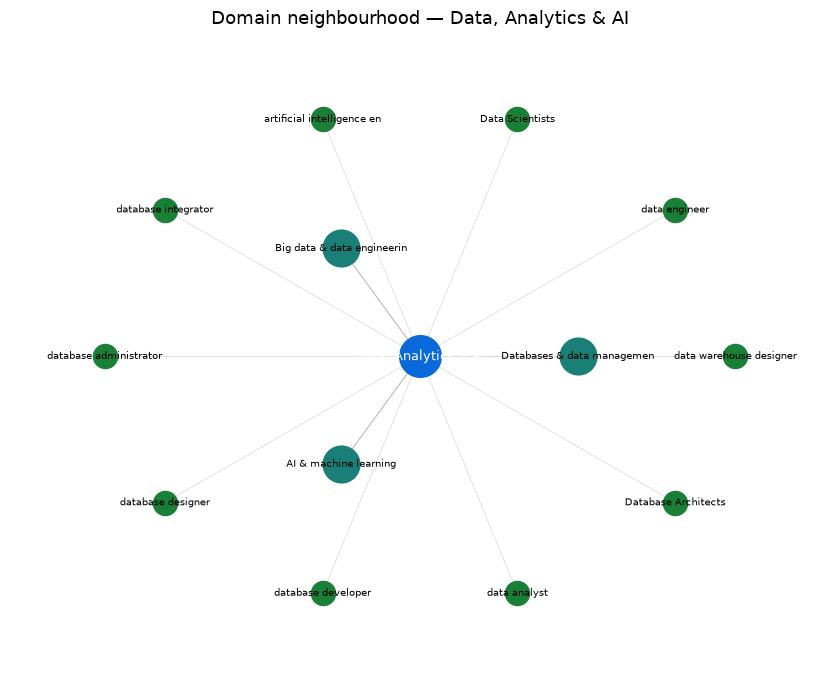

In [20]:
# small node-link diagram of one functional domain: its categories + a sample of its occupations
byid = {n['id']: n for n in nodes}
dom = next((n for n in nodes if n['kind'] == 'skill_domain' and 'Data' in (n['label_en'] or '')), None)
cats = [byid[e['source']] for e in edges if e['type'] == 'broader' and e['target'] == dom['id']
        and byid[e['source']]['kind'] == 'skill_category']
occs = [byid[e['source']] for e in edges if e['type'] == 'in_domain' and e['target'] == dom['id']][:10]
fig, ax = plt.subplots(figsize=(8.5, 7)); ax.axis('off')
ax.set_title(f"Domain neighbourhood — {dom['label_en']}", fontsize=13)
def ring(items, radius, color, size):
    pts = {}
    for i, n in enumerate(items):
        a = 2 * math.pi * i / max(1, len(items))
        x, y = radius * math.cos(a), radius * math.sin(a); pts[n['id']] = (x, y)
        ax.scatter([x], [y], s=size, color=color, zorder=3)
        ax.annotate(n['label_en'][:26], (x, y), fontsize=7.5, ha='center', va='center', zorder=4)
    return pts
ax.scatter([0], [0], s=900, color='#0969da', zorder=3); ax.annotate(dom['label_en'], (0, 0), fontsize=9, ha='center', va='center', color='white', zorder=4)
cp = ring(cats, 1.0, '#1a7f76', 700); op = ring(occs, 2.0, '#1a7f37', 300)
for n in cats: ax.plot([0, cp[n['id']][0]], [0, cp[n['id']][1]], color='#bbb', lw=0.8, zorder=1)
for n in occs: ax.plot([0, op[n['id']][0]], [0, op[n['id']][1]], color='#ddd', lw=0.6, zorder=1)
ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6); plt.tight_layout(); plt.show()